# Understanding Transformers Through Complexity and Cost
## A Ladder of Architectures for English and Tagalog/Taglish Sarcasm Detection
**Machine Learning 3, Mini Project 2, MSDS 2026**


In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from src import config
from src.viz import plot_complexity_ladder, plot_transfer_collapse

RESULTS = config.RESULTS_DIR
results_df = pd.read_csv(f"{RESULTS}/results_full.csv")
summary_df = pd.read_csv(f"{RESULTS}/summary_df.csv")
stats_df   = pd.read_csv(f"{RESULTS}/stats_df.csv")

TRAINED   = summary_df[summary_df["model_family"] != "llm_reference"]
REFERENCE = summary_df[summary_df["model_family"] == "llm_reference"]
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1 Executive Summary

The team built this project to understand how much model complexity is actually useful for a low-resource sarcasm detection problem. We framed sarcasm detection as binary text classification across English and Tagalog/Taglish, then tested a ladder of models: a TF-IDF baseline, TextCNN, BiGRU, from-scratch single-head, multi-head, and stacked Transformer-encoder classifiers, fine-tuned multilingual DistilBERT, mBERT, and XLM-R models, and a zero-shot LLM reference. We chose this ladder because it let us compare performance, parameter cost, training time, and language-transfer behavior within one task.

What the team learned was that, on this small dataset (483 training examples), **added architectural complexity did not reliably improve performance**. The TF-IDF baseline reached 0.650 macro-F1 in EN to EN, matching or exceeding every from-scratch and fine-tuned neural model. We also observed that from-scratch attention collapsed sharply under cross-lingual transfer (EN to TL), while target-language fine-tuning (TL to TL) recovered much of that loss. The zero-shot LLM reference (0.724 macro-F1 on TL) outperformed all trained models, which showed us that capability in this setting came more from large-scale pretraining than from architectural complexity alone. Based on this finding, we recommend starting with a strong classical baseline or a pretrained multilingual model for low-resource Taglish sarcasm detection, and treating an LLM as a cost-bearing upper reference rather than as a direct level-playing-field competitor.


## 2 Introduction

The team chose sarcasm detection because it is a practical language problem where literal text can be misleading. In sarcasm, the intended meaning of an utterance often contradicts its wording, and the cue is frequently carried by surrounding conversational context. We formulated the task as binary classification: given a target utterance with its preceding context, predict *sarcastic* or *not sarcastic*.

Beyond raw accuracy, we wanted to use the project as an experiential comparison of model design choices. As we climbed a ladder of increasingly complex architectures, we asked whether each rung earned its added parameters and compute. The team deliberately recapitulated the historical progression taught in the course, classical features, CNNs, RNNs, attention, and the Transformer, as a controlled experiment on one task, then extended the comparison to a zero-shot LLM reference.

**Objective.** We aimed to quantify the complexity-payoff trade-off for sarcasm detection, and to measure how well models transfer between English and Tagalog/Taglish.

**Scope and limitations.** The team recognizes that the dataset is small (690 aligned examples per language) and text-only, whereas the original MUStARD is multimodal. We treated this as a limitation because sarcasm can depend on audio, visual delivery, or speaker context. This means the findings should be interpreted as evidence about the small-data, text-only regime, not as a general claim about sarcasm detection.


## 3 Business Value

The team treated Filipino/Taglish sarcasm detection as a practical business problem because Tagalog/Taglish is a low-resource language for NLP yet a dominant language of Philippine social media and customer interaction. Sarcasm can routinely defeat naive sentiment and moderation filters: a sarcastic complaint may be scored as positive, while sarcastic hostility may evade detection.

We used the project as a concrete build-versus-buy decision exercise for organizations doing Philippine social listening or content moderation. The team wanted to understand whether an English-trained model can be reused for Taglish, whether local fine-tuning is necessary, or whether a pay-per-call LLM is the better option. Our EN to TL versus TL to TL comparison addresses the first two questions, and the complexity ladder shows how much model capacity and compute budget is actually needed to clear a useful accuracy bar. For cost-constrained deployment, the finding that a cheap TF-IDF model is competitive has direct budget implications.


## 4 Data

**Source.** The team worked with the text-only MUStARD sarcasm dataset for English. Each item has a conversational context, a target utterance, and a binary sarcasm label. We also used an aligned Tagalog/Taglish version of the same items, carrying both its own label (`sarcasm_tl`) and the original English label, which allowed us to measure label shift.

**Why this data fits the modeling task.** We considered the dataset suitable for RNN and Transformer-style models because each example is a sequence of words with context and utterance structure. The task also tests whether sequence-aware models can use conversational context better than simpler lexical baselines.

**Translation provenance.** The Taglish data was produced by machine-translating MUStARD, then validating with three human raters, judging for naturalness, and re-translating toward more natural Taglish where needed. Inter-rater reliability was calculated for the human validation step, resulting in a Fleiss' $\kappa$ = 0.5652. We were still able to quantify label shift: 29.0% of TL labels differ from the English original. This reminded the team that translation is not just a surface text change, it can also shift the sarcastic meaning being labeled.

**Size and split.** We found 690 aligned examples per language. The 70/30 id-level split produces 207 test examples; in the reported results, the most common experimental configuration used 483 train examples and 207 test examples, with validation carved from the training portion for tuned runs. The split is performed on the original conversation id rather than on rows, preventing the same item from leaking across train and test in different languages.

**Preprocessing.** Missing context/utterance fields are filled as empty strings; inputs are constructed as `[CONTEXT] ... [UTTERANCE] ...`. We used this input format so that models could distinguish the prior context from the target utterance.


In [2]:
from src.data import load_all_data
from src.eda import run_eda, compute_fleiss_kappa
df_all = load_all_data()
label_shift_df = run_eda(df_all)

,lang,n_rows
0,EN,690
1,TL,690


,lang,label,count,percent
0,EN,0,345,50.00000
1,EN,1,345,50.00000
2,TL,0,341,49.42029
3,TL,1,349,50.57971


utt_wc                    ctx_wc                
           mean median min max       mean median min  max
lang                                                     
EN    12.443478   11.0   1  65  36.872464   32.0   1  126
TL    12.431884   11.0   1  57  36.508696   32.0   1  112

,lang,sum,count,mean,percent_changed
0,TL,200,690,0.289855,28.985507


**Table 1. Data audit tables.** The displayed EDA tables summarize row counts, class balance, text-length distributions, and Tagalog/Taglish label shift. The team used these checks to confirm that the task is small, aligned across languages, and sensitive to translation-related label changes before interpreting model performance.


## 5 Methodology

The team adopted a **two-act design: optimize first, then test generalizability.** We designed the experiment this way so that we could separate model-building questions from language-transfer questions.

**Act 1 (Optimize, EN to EN).** We held the setting fixed and climbed the architecture ladder, tuning each model and recording macro-F1, parameter count, and training time:

1. TF-IDF + Logistic Regression / Linear SVM (classical floor)
2. TextCNN (convolutional)
3. BiGRU (recurrent)
4. Single-head self-attention (QKV implemented from scratch)
5. Multi-head attention
6. N-layer Transformer encoder (positional encoding; depths 1/2/4)
7. Pretrained multilingual Transformer (DistilBERT / mBERT / XLM-R)

We included the TF-IDF models and the **majority-class baseline** so that the neural architectures had to prove that they added value beyond simple lexical and chance floors. We chose TextCNN and BiGRU to test whether local patterns or recurrent sequence structure helped. We then added from-scratch attention and Transformer encoders to test whether the course architectures could learn useful context patterns from limited data. Finally, we included pretrained multilingual Transformers to test whether external pretraining changed the complexity-payoff tradeoff.

We also ran encoder ablations in EN to EN only, covering number of heads, number of layers, and sinusoidal, learnable, or no positional encoding. The team used these ablations to understand whether extra Transformer capacity was helping, or whether the dataset size was the binding constraint.

**Regularization.** Neural models used dropout, weight decay, a carved validation split, and early stopping on validation macro-F1. We used these safeguards because the dataset was small and overfitting was a realistic risk.

**Act 2 (Generalize).** We evaluated the tuned models across all three settings, EN to EN, EN to TL, and TL to TL, over 10 random seeds. We reported mean +/- std and used paired Wilcoxon tests for transfer cost and fine-tuning benefit. This setup let the team compare reuse of English-trained models against target-language training.

**Reference tier.** A zero-shot LLM (OpenAI GPT-4o mini) judged each test utterance in-language. We treated the LLM as a reference tier rather than a direct production model because it was not trained on our split and has much broader pretraining than the models we trained.

**Evaluation.** The primary metric is macro-F1 because both classes matter, with accuracy and sarcasm-class F1 reported alongside.


**Reproducibility note.** The report loads committed CSV outputs from `results/` and does not retrain models. To reproduce the environment, create it from `environment.yml`; to regenerate outputs, run `python run_experiments.py`; to validate lightweight code behavior, run `pytest -q` and `ruff check src tests`. Full regeneration can be slow because it includes multi-seed neural and pretrained Transformer runs.


## 6 Results and Discussion

The team organized the results by research question so that each experiment answered a specific design decision. Throughout the discussion, we reported trained models separately from the LLM reference tier because the latter was not trained on our split.


,model_family,model_name,mean_macro_f1,std_macro_f1,mean_params,mean_train_time_s
39,baseline,majority_floor,0.332258,0.000000,0.0,NaN
2,classical,tfidf_logreg,0.649971,0.029249,16557.9,0.35808
3,classical,tfidf_svm,0.649324,0.027239,16557.9,0.06768
19,scratch_transformer,single_head_attn,0.560350,0.067165,594293.2,0.77500
26,scratch_transformer,multi_head_attn,0.547768,0.041290,610805.2,0.69200
8,cnn_rnn,bigru,0.597814,0.047880,619253.2,0.79700
10,cnn_rnn,text_cnn,0.594189,0.043536,643381.2,0.85600
12,scratch_transformer,abl_layers1,0.589530,0.041173,677237.2,1.30100
23,scratch_transformer,abl_pos_none,0.554449,0.044790,809717.2,1.58000
25,scratch_transformer,abl_heads1,0.549281,0.049632,809717.2,1.82200


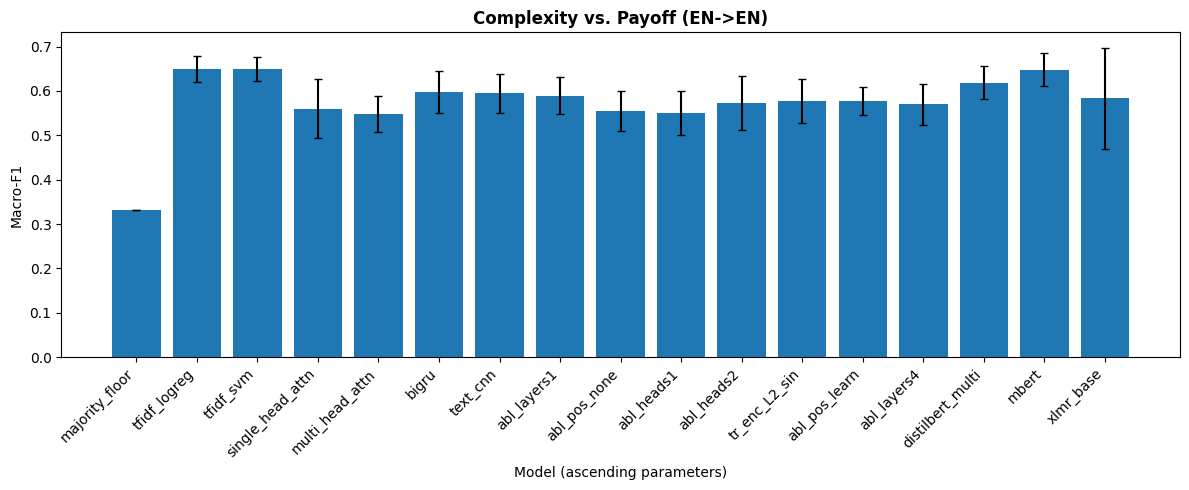

In [3]:
# RQ3: complexity ladder for in-language English results
rq3_table = TRAINED[TRAINED["setting"] == "EN->EN"].copy()
display(rq3_table[["model_family", "model_name", "mean_macro_f1", "std_macro_f1", "mean_params", "mean_train_time_s"]]
        .sort_values("mean_params"))

fig, ax = plot_complexity_ladder(rq3_table)
fig.savefig(os.path.join(FIGURES_DIR, "complexity_ladder.png"), dpi=160, bbox_inches="tight")
plt.show()


**Figure 1. Complexity ladder for EN to EN sarcasm detection.** Models are ordered by parameter count, and bar height shows mean macro-F1 across seeds. The figure uses the existing `results/summary_df.csv` values and is saved to `figures/complexity_ladder.png`. The team used this figure to compare performance gains against model size and training cost.


### 6.1 RQ3, Complexity vs. Payoff

**Figure 1** (above) shows EN to EN macro-F1 against models ordered by parameter count. The team expected larger architectures to help, but the result contradicted that intuition: the **TF-IDF baseline (0.650 macro-F1) was the strongest trained model in EN to EN**, matching or exceeding both the from-scratch attention rungs (single-head 0.560, multi-head 0.548, encoder 0.577) and the fine-tuned multilingual Transformers (mBERT 0.648 to XLM-R 0.583), despite the latter having three to four orders of magnitude more parameters.

This result showed us that complexity has to be justified by the data regime. First, **from-scratch attention did not beat the bag-of-words floor** on 483 training examples. We realized there was too little data to learn useful attention patterns from scratch. Second, contrary to our original hypothesis, **pretraining did not produce a decisive advantage** here either: the best pretrained model was close to, but did not clearly exceed, TF-IDF in EN to EN. The payoff for complexity, in this small text-only regime, was essentially flat.

The ablation runs (heads in {1,2,4}; layers in {1,2,4}; positional encoding sinusoidal/learnable/none) likewise showed limited payoff from extra capacity: the one-layer encoder was highest at 0.590 macro-F1, while the two-layer sinusoidal encoder scored 0.577 and the four-layer version scored 0.570. Changing heads stayed close and variable (1 head 0.549, 2 heads 0.573, 4 heads 0.577), and learnable positional encoding essentially tied sinusoidal encoding (0.577 vs. 0.577), while removing positional encoding was lower at 0.554. This reinforced our interpretation that data, not capacity, was the binding constraint.

For business use, this tradeoff matters because a larger model does not automatically create better decisions. In this task, the team observed that a cheaper and more interpretable baseline can be a stronger starting point than a bespoke neural architecture.


The next table and Figure 2 compare in-language English performance with English-to-Tagalog/Taglish transfer for trained models only. The team used this comparison to test whether models trained on English could be reused in the target-language setting.


,model_family,model_name,setting,input_variant,mean_macro_f1,std_macro_f1,mean_sarcasm_f1,std_sarcasm_f1,mean_accuracy,std_accuracy,n_runs,mean_params,mean_train_time_s
25,scratch_transformer,abl_heads1,EN->EN,context_utterance,0.549281,0.049632,0.489399,0.109422,0.567633,0.038056,10,809717.2,1.82200
17,scratch_transformer,abl_heads2,EN->EN,context_utterance,0.572868,0.060462,0.536217,0.120509,0.588889,0.047794,10,809717.2,1.94300
12,scratch_transformer,abl_layers1,EN->EN,context_utterance,0.589530,0.041173,0.564273,0.085545,0.597585,0.039382,10,677237.2,1.30100
18,scratch_transformer,abl_layers4,EN->EN,context_utterance,0.570229,0.045983,0.545257,0.051730,0.578261,0.048043,10,1074677.2,3.34500
15,scratch_transformer,abl_pos_learn,EN->EN,context_utterance,0.577119,0.031969,0.548201,0.062455,0.584058,0.032562,10,834293.2,1.81500
23,scratch_transformer,abl_pos_none,EN->EN,context_utterance,0.554449,0.044790,0.468416,0.101402,0.577295,0.030319,10,809717.2,1.58000
8,cnn_rnn,bigru,EN->EN,context_utterance,0.597814,0.047880,0.566173,0.093206,0.609179,0.041523,10,619253.2,0.79700
33,cnn_rnn,bigru,EN->TL,context_utterance,0.438629,0.068430,0.352414,0.239416,0.510145,0.020138,10,619253.2,0.79300
5,transformer,distilbert_multi,EN->EN,context_utterance,0.618897,0.037294,0.593576,0.071941,0.625121,0.033017,10,135326210.0,5.74900
31,transformer,distilbert_multi,EN->TL,context_utterance,0.530807,0.068618,0.546437,0.159007,0.557488,0.051389,10,135326210.0,5.69700


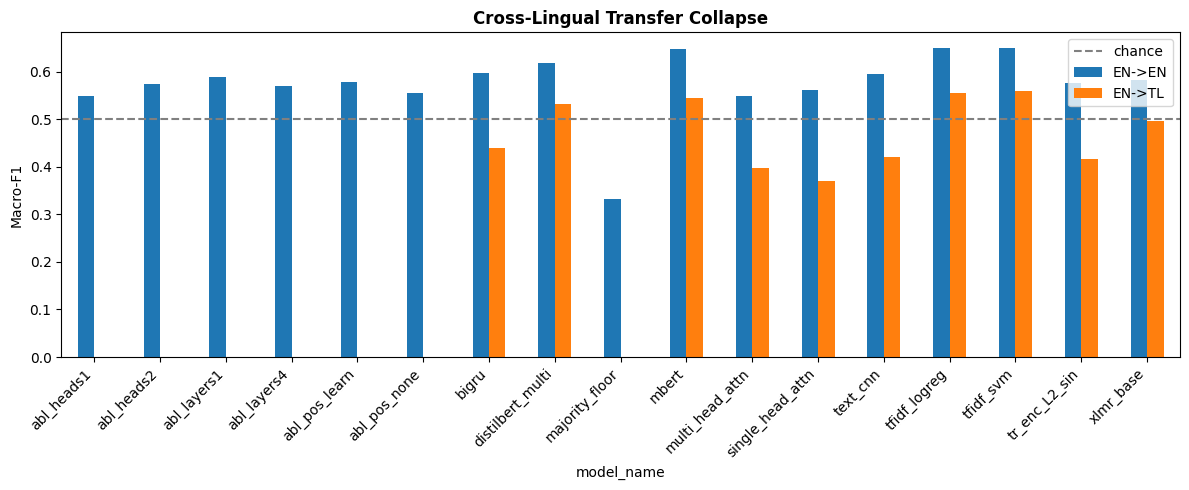

In [4]:
# RQ1: EN->EN vs EN->TL for trained models
rq1 = (TRAINED[TRAINED["setting"].isin(["EN->EN", "EN->TL"])]
       .sort_values(["model_name", "setting"]))
display(rq1)

fig, ax = plot_transfer_collapse(TRAINED)
plt.show()

**Table 2 and Figure 2. Cross-lingual transfer comparison.** The table reports the summarized model metrics, while Figure 2 visualizes the macro-F1 change between EN to EN and EN to TL. The surrounding discussion interprets which model families degraded most under transfer and what that means for deployment.


### 6.2 RQ1, Cross-Lingual Transfer

**Figure 2** contrasts EN to EN and EN to TL macro-F1. We found that transfer weakened performance for every trained model, but **not uniformly**, and that pattern became the substantive finding:

- **Scratch neural models collapsed.** Single-head (-0.190), multi-head (-0.151), the encoder (-0.161), TextCNN (-0.173), and BiGRU (-0.159) dropped sharply toward chance. Their vocabularies were English-only, so Tagalog test tokens were largely unseen; structurally, they could not transfer well.
- **TF-IDF did not collapse.** It dropped more modestly (-0.096) and remained one of the better EN to TL models, likely because shared tokens, English loanwords, names, and code-switched fragments common in Taglish still carried signal.
- **Pretrained multilingual models dropped least overall**, retaining more performance because they used shared subword vocabularies across languages.

This result taught the team that cross-lingual transfer is not only about architecture type. Tokenization, vocabulary overlap, and pretraining matter directly. We therefore **rejected the strong form of our original hypothesis**, which assumed that only pretrained models would transfer. TF-IDF also transferred competitively. The more accurate claim is that *from-scratch neural models* collapsed, while classical and pretrained multilingual models degraded more gracefully. We did not find a single overall RQ1 p-value in the provided results, so we used the available model-level paired Wilcoxon tests: single-head p=0.002, multi-head p=0.002, encoder p=0.006, TextCNN p=0.004, BiGRU p=0.002, and TF-IDF p=0.002.

For a business team, this means that reusing an English-trained scratch model for Taglish would be risky. The safer practical choices are a multilingual pretrained model, a carefully validated classical baseline, or target-language training where labels are available.


The following tables summarize target-language fine-tuning and the paired statistical comparisons used for RQ2. The team used these tables to decide whether collecting or labeling target-language data changes the model recommendation.


In [5]:
# RQ2: EN->TL vs TL->TL for trained models
rq2 = (TRAINED[TRAINED["setting"].isin(["EN->TL", "TL->TL"])]
       .sort_values(["model_name", "setting"]))
display(rq2)

# paired significance (transfer cost and fine-tuning benefit)
display(stats_df)

,model_family,model_name,setting,input_variant,mean_macro_f1,std_macro_f1,mean_sarcasm_f1,std_sarcasm_f1,mean_accuracy,std_accuracy,n_runs,mean_params,mean_train_time_s
33,cnn_rnn,bigru,EN->TL,context_utterance,0.438629,0.068430,0.352414,0.239416,0.510145,0.020138,10,619253.2,0.79300
27,cnn_rnn,bigru,TL->TL,context_utterance,0.546004,0.052143,0.592600,0.098550,0.560870,0.054248,10,637698.0,0.81900
31,transformer,distilbert_multi,EN->TL,context_utterance,0.530807,0.068618,0.546437,0.159007,0.557488,0.051389,10,135326210.0,5.69700
7,transformer,distilbert_multi,TL->TL,context_utterance,0.601135,0.021061,0.617348,0.044564,0.604348,0.022249,10,135326210.0,5.68200
40,baseline,majority_floor,TL->TL,context_utterance,0.329766,0.009042,0.533716,0.273910,0.492271,0.019881,10,0.0,NaN
29,transformer,mbert,EN->TL,context_utterance,0.543720,0.081681,0.588701,0.130253,0.575845,0.060630,10,177854978.0,9.96100
9,transformer,mbert,TL->TL,context_utterance,0.595449,0.025325,0.626873,0.049909,0.600966,0.025174,10,177854978.0,10.00300
37,scratch_transformer,multi_head_attn,EN->TL,context_utterance,0.397225,0.078723,0.208633,0.253426,0.495652,0.025985,10,610805.2,0.70000
28,scratch_transformer,multi_head_attn,TL->TL,context_utterance,0.544990,0.025169,0.596803,0.054882,0.559420,0.021094,10,629250.0,0.74100
38,scratch_transformer,single_head_attn,EN->TL,context_utterance,0.370404,0.064086,0.200699,0.267485,0.494203,0.026563,10,594293.2,0.76000


,model_name,a,b,n_pairs,mean_a,mean_b,delta,p_value,note
0,abl_heads1,EN->EN,EN->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
1,abl_heads1,EN->TL,TL->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
2,abl_heads2,EN->EN,EN->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
3,abl_heads2,EN->TL,TL->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
4,abl_layers1,EN->EN,EN->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
5,abl_layers1,EN->TL,TL->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
6,abl_layers4,EN->EN,EN->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
7,abl_layers4,EN->TL,TL->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
8,abl_pos_learn,EN->EN,EN->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds
9,abl_pos_learn,EN->TL,TL->TL,0,NaN,NaN,NaN,NaN,need >=2 seeds


**Table 3. Target-language fine-tuning and paired comparisons.** The first table contrasts EN to TL and TL to TL model summaries, and the second table reports paired Wilcoxon comparisons across matched seeds where available. These tables show where local Taglish training recovered transfer loss and where the evidence was weaker.


### 6.3 RQ2, Target-Language Fine-Tuning

Training directly on Taglish (TL to TL) versus transferring from English (EN to TL) helped **most** models, but the evidence was not uniform:

- **Scratch and lower models improved clearly and significantly.** BiGRU (0.107, p=0.006), TextCNN (0.136, p=0.004), single-head attention (0.167, p=0.002), and the encoder (0.144, p=0.010) all recovered much of their transfer loss.
- **Pretrained models improved, but with weaker evidence for some models.** With 10 seeds, DistilBERT gained 0.070 (p=0.006) and mBERT gained 0.052 (p=0.084).
- **XLM-R was the exception.** It performed *worse* on TL to TL (-0.069, p=0.129) and showed high seed-to-seed variance, contradicting the simple claim that target-language training always helps.

This result clarified a practical tradeoff for the team. Target-language fine-tuning generally helps, especially for models that could not transfer well from English, but it is not a universal guarantee. We explicitly flagged XLM-R's instability rather than averaging it away. Based on this evidence, the team would justify local Taglish labeling when the deployment target is Taglish, while still validating the chosen model family rather than assuming fine-tuning always improves performance.


The RQ4 tables place the zero-shot LLM reference beside the best trained in-language model for context, without treating the LLM as a level-playing-field competitor. The team used this comparison to understand what a large pretrained system can provide as an upper reference.


In [6]:
# RQ4: LLM reference vs trained ceiling, in-language
display(REFERENCE.sort_values("setting"))
# Best trained model per setting, for side-by-side context
best_trained = (TRAINED.sort_values("mean_macro_f1", ascending=False)
                .groupby("setting").head(1))
display(best_trained[["setting", "model_name", "mean_macro_f1"]])

,model_family,model_name,setting,input_variant,mean_macro_f1,std_macro_f1,mean_sarcasm_f1,std_sarcasm_f1,mean_accuracy,std_accuracy,n_runs,mean_params,mean_train_time_s
1,llm_reference,openai_openai_gpt-4o-mini,EN->EN,context_utterance,0.661012,NaN,0.733068,NaN,0.676329,NaN,1,NaN,NaN
0,llm_reference,openai_openai_gpt-4o-mini,TL->TL,context_utterance,0.723645,NaN,0.789062,NaN,0.739130,NaN,1,NaN,NaN


,setting,model_name,mean_macro_f1
2,EN->EN,tfidf_logreg,0.649971
6,TL->TL,tagalog_roberta,0.608338
21,EN->TL,tfidf_svm,0.558389


**Table 4. Reference ceiling context.** The first table shows the cached LLM reference results, and the second table lists the best trained model per setting. These values come from the committed result CSVs and are used only as context for the trained-model results.


### 6.4 RQ4, Reference Ceilings

**LLM reference.** A zero-shot OpenAI GPT-4o mini judge reached 0.661 macro-F1 in English and 0.724 macro-F1 in Taglish, **above every trained model in both settings**. It was strongest on Taglish, suggesting that its multilingual pretraining handled code-switching better than anything we could train on 483 examples. This result showed the team that capability tracked pretraining scale more than architectural sophistication alone.

**Caveats (important for fair comparison).** The team treated the LLM as **not a level-playing-field competitor**: it was not trained on our split and has vastly more pretraining, so it sits in a separate reference tier. We evaluated only a single zero-shot prompt setting, with no few-shot variant. Because predictions were precomputed and cached, **per-call cost and latency were not recorded; we therefore make no cost-based claims** and treat the LLM purely as an accuracy reference. MUStARD is public, so contamination, meaning the model may have seen it during pretraining, cannot be ruled out.

**Published MUStARD context.** Prior MUStARD work is **multimodal** (text + audio + video) and reports higher figures than our text-only setting. We discussed those numbers as literature context, not as head-to-head competitors, because the modality and splits differ. No published Tagalog/Taglish MUStARD baseline exists, which is itself a gap this work begins to fill.


## 7 Conclusion

The team set out to measure the complexity-payoff trade-off in sarcasm detection and to test cross-lingual transfer between English and Taglish. Three lessons stand out from the project.

First, **complexity did not pay off** in our small, text-only regime: a TF-IDF baseline matched or beat every from-scratch and fine-tuned neural model in EN to EN. Second, **transfer behavior split by model family**: from-scratch neural models collapsed on EN to TL, while TF-IDF and pretrained multilingual models degraded more gracefully. Target-language fine-tuning recovered most of the loss for the weaker models, though not uniformly, with XLM-R serving as an instructive exception. Third, **a zero-shot LLM outperformed all trained models**, most clearly on Taglish, indicating that the decisive factor was large-scale pretraining rather than architectural sophistication alone.

The main learning for the team is that architecture should be chosen in relation to data scale, language setting, cost, and deployment constraints. On low-resource, small-data sarcasm tasks, architectural complexity is not the lever it is often assumed to be. A strong classical baseline, a pretrained multilingual model, or an LLM reference are each more rational starting points than a bespoke from-scratch Transformer.


## 8 Recommendation

- **For practitioners (short term).** Based on what we observed, we recommend starting with TF-IDF + logistic regression as a baseline for Taglish sarcasm; it is cheap, robust, and surprisingly hard to beat at this data scale. The team would reserve neural models for settings where substantially more labelled data is available.
- **For cross-lingual deployment.** We do not recommend reusing a from-scratch English-trained model on Taglish, because it collapses. The team would prioritize a pretrained multilingual model, and where feasible, fine-tune on target-language data, which significantly helps most models.
- **For an accuracy ceiling.** A zero-shot LLM is the strongest option, especially for code-switched Taglish; we recommend treating it as a reference or high-value fallback, with the caveat that cost and latency must be measured before production use.
- **For the next iteration.** The team would acquire more labelled Taglish data because data was the binding constraint in our results. We also recommend measuring LLM cost and latency directly, exploring few-shot prompting, and comparing against published multimodal MUStARD results where the modalities and splits are clearly separated.


## Member Contribution

| Member | Contributions |
|--------|---------------|
| Doria, Michelle Joanna | Data pipeline, EDA, data section, label-shift analysis |
| Inciso, Leonard Ray | Classical baselines, TextCNN/BiGRU models, regularization |
| Moran, Maria Patricia | From-scratch attention ladder, Transformer encoder ablations |
| Pascual, Ronald Patrick | Pretrained models, LLM reference, statistics, CI/tests |

The current repository contains the final consolidated project state. Future iterations should use smaller, logically scoped commits for data, modeling, testing, and reporting.


## References

- Castro, S., et al. (2019). *Towards Multimodal Sarcasm Detection (An Obviously Perfect Paper).* ACL. (MUStARD dataset)
- Vaswani, A., et al. (2017). *Attention Is All You Need.* NeurIPS.
- Chollet, F., & Watson, M. (2026). *Deep Learning with Python*, 3rd ed. Manning.
- Zhang, A., et al. (2023). *Dive into Deep Learning.* Cambridge.
- Hugging Face model cards used in the project: `distilbert-base-multilingual-cased`, `bert-base-multilingual-cased`, `xlm-roberta-base`, and `jcblaise/roberta-tagalog-base`.
- LLM used: OpenAI gpt-4o-mini; cached predictions in data/llm_predictions_all_languages.csv; access date not recorded in the provided data.
- Additional source note: LLM assistance was used for development support and report drafting; all reported metrics are computed from the committed data and results files.


## Acknowledgements

We thank our three annotators for validating the Tagalog/Taglish translations, and the ML3 teaching team for guidance.
